In [ ]:
# Shreyaj Padigala
from __future__ import unicode_literals, print_function, division
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.functional import gumbel_softmax
from torch.distributions.categorical import Categorical
from sklearn import preprocessing
import matplotlib.pyplot as plt
import time
import random

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# Use CPU for Surface Go 2 (limited GPU memory)
device = torch.device('cpu')
print(f"Using device: {device}")

Using device: cpu


In [ ]:
# CELL 2: Data Management Class

class TextData:
    """
    Fixed version - properly handles batch labels
    """

    def __init__(self, path='data.csv'):
        print("Loading TED talks data...")
        self.load(path)
        self.setup_encoders()
        self.create_data_matrix()
        self.position = 0

    def load(self, path):
        """Load and preprocess TED talks data"""
        try:
            df = pd.read_csv(path)
            self.raw_text = " ".join(df['title'].fillna("").astype(str))
            print(f"Loaded {len(df)} TED talks")
            print(f"Total text length: {len(self.raw_text)} characters")
        except FileNotFoundError:
            print(f"Error: Could not find {path}")
            raise

    def setup_encoders(self):
        """Setup character vocabulary and encoders"""
        chars = sorted(list(set(self.raw_text.lower())))
        chars = [c for c in chars if c.isalnum() or c in ' .,!?-']

        print(f"Extracted characters:")
        print(chars)

        self.n_chars = len(chars)
        self.chars = chars

        self.char_to_idx = {ch: i for i, ch in enumerate(chars)}
        self.idx_to_char = {i: ch for i, ch in enumerate(chars)}

        self.le = preprocessing.LabelEncoder()
        self.le.fit(chars)

    def create_data_matrix(self):
        """Convert text to indices"""
        clean_text = ''.join([c.lower() if c.lower() in self.char_to_idx else ' '
                             for c in self.raw_text])

        self.data_indices = [self.char_to_idx[c] for c in clean_text]

        print(f"Text Data Shape: ({len(self.data_indices)},)")
        print(f"Vocabulary size: {self.n_chars}")

    def slices(self, seq_len, n_proc):
        """
        FIXED: Create training slices with correct label dimensions
        """
        data_len = len(self.data_indices)

        if self.position + seq_len >= data_len:
            self.position = 0

        # FIXED: Labels tensor now has correct shape [seq_len, n_proc]
        batch = torch.zeros(seq_len, n_proc, self.n_chars)
        batch_l = torch.zeros(seq_len, n_proc, dtype=torch.long)  # ← FIXED: Added n_proc dimension
        resets = np.zeros(n_proc)

        for i in range(seq_len):
            for j in range(n_proc):
                # Current character for this process
                process_pos = (self.position + i + j) % data_len
                char_idx = self.data_indices[process_pos]
                batch[i, j, char_idx] = 1.0

                # FIXED: Target label for this process
                next_pos = (self.position + i + j + 1) % data_len
                batch_l[i, j] = self.data_indices[next_pos]  # ← FIXED: Now includes j dimension

        self.position = (self.position + seq_len) % data_len

        return batch.to(device), batch_l.to(device), resets

    def print_str(self, onehot_tensor):
        """Print one-hot tensor as string"""
        chars = []
        for i in range(onehot_tensor.shape[0]):
            char_idx = torch.argmax(onehot_tensor[i]).item()
            if char_idx < len(self.chars):
                chars.append(self.chars[char_idx])
            else:
                chars.append('?')
        print(''.join(chars))

print("FIXED TextData class defined!")

FIXED TextData class defined!


In [ ]:
class network_state:
    """
    Manages hidden states for hierarchical RNN layers
    Exactly matching original implementation naming
    """

    def __init__(self, hidden_size, n_proc):
        self.hidden_size = hidden_size
        self.n_proc = n_proc

        # Initialize hidden states (matching original structure)
        self.rnn1 = torch.zeros(n_proc, hidden_size).to(device)
        self.rnn2 = torch.zeros(n_proc, hidden_size).to(device)
        self.rnn3 = torch.zeros(n_proc, hidden_size).to(device)
        self.rnn4 = torch.zeros(n_proc, hidden_size).to(device)

        # Boundary gates
        self.b1 = torch.zeros(n_proc, 1).to(device)
        self.b2 = torch.zeros(n_proc, 1).to(device)
        self.b3 = torch.zeros(n_proc, 1).to(device)

    def reset_hidden(self, resets):
        """Reset hidden states where needed"""
        for i, should_reset in enumerate(resets):
            if should_reset:
                self.rnn1[i] = 0
                self.rnn2[i] = 0
                self.rnn3[i] = 0
                self.rnn4[i] = 0
                self.b1[i] = 0
                self.b2[i] = 0
                self.b3[i] = 0

    def detach(self):
        """Detach from computation graph"""
        self.rnn1 = self.rnn1.detach()
        self.rnn2 = self.rnn2.detach()
        self.rnn3 = self.rnn3.detach()
        self.rnn4 = self.rnn4.detach()
        self.b1 = self.b1.detach()
        self.b2 = self.b2.detach()
        self.b3 = self.b3.detach()

In [ ]:
class RNN(nn.Module):
    """
    Hierarchical RNN implementation
    Optimized for Surface Go 2 with reduced complexity
    """

    def __init__(self, hidden_size, vocab_size, n_proc, gumbel_hard):
        super(RNN, self).__init__()

        self.hidden_size = hidden_size
        self.vocab_size = vocab_size
        self.n_proc = n_proc
        self.gumbel_hard = gumbel_hard

        # Character embedding (matching original names)
        self.e_ct = nn.Linear(vocab_size, hidden_size)

        # RNN layers with boundary conditions (exact original structure)
        self.rnn1_b0 = nn.Linear(hidden_size * 2, hidden_size)
        self.rnn1_b1 = nn.Linear(hidden_size * 2, hidden_size)
        self.b1_rnn1 = nn.Linear(hidden_size, 2)

        self.rnn2_b0 = nn.Linear(hidden_size * 2, hidden_size)
        self.rnn2_b1 = nn.Linear(hidden_size * 2, hidden_size)
        self.b2_rnn2 = nn.Linear(hidden_size, 2)

        self.rnn3_b0 = nn.Linear(hidden_size * 2, hidden_size)
        self.rnn3_b1 = nn.Linear(hidden_size * 2, hidden_size)
        self.b3_rnn3 = nn.Linear(hidden_size, 2)

        self.rnn4 = nn.Linear(hidden_size * 2, hidden_size)

        # Output layers (matching original names)
        self.hg_rnns = nn.Linear(hidden_size * 4, hidden_size)
        self.g_hg = nn.Linear(hidden_size, 4)
        self.hctpi_rnns = nn.Linear(hidden_size * 4, hidden_size)
        self.ctpi_hctpi = nn.Linear(hidden_size, vocab_size)

        # Activation functions
        self.tanh = nn.Tanh()
        self.sigmoid = nn.Sigmoid()
        self.relu = nn.ReLU()
        self.softmax = nn.LogSoftmax(dim=1)

        # Move to device
        self.to(device)

        print(f"Created RNN with {sum(p.numel() for p in self.parameters())} parameters")

    def weight_init(self, mean, std):
        """Initialize weights with Gaussian distribution"""
        for param in self.parameters():
            param.data.normal_(mean, std)

    def first_step(self, state):
        """Generate first prediction from initial state"""
        # Combine all RNN states
        combined = torch.cat([state.rnn1, state.rnn2, state.rnn3, state.rnn4], dim=1)

        # Apply output layers
        h = self.tanh(self.hg_rnns(combined))
        gates = self.sigmoid(self.g_hg(h))

        h_out = self.tanh(self.hctpi_rnns(combined))
        output = self.softmax(self.ctpi_hctpi(h_out))

        return output

    def forward(self, ct, state, theta):
        """
        Forward pass through hierarchical RNN
        Matching original implementation exactly
        """
        # Embed input character
        ct_e = self.tanh(self.e_ct(ct.squeeze(0)))

        # Layer 1: Always updates (matching original logic)
        rnn1_input = torch.cat([state.rnn1, ct_e], dim=1)
        rnn1b0 = self.tanh(self.rnn1_b0(rnn1_input))
        rnn1b1_input = torch.cat([state.rnn2, ct_e], dim=1)
        rnn1b1 = self.tanh(self.rnn1_b1(rnn1b1_input))

        # Boundary decision for layer 1
        b1_logits = self.b1_rnn1(rnn1b0)
        b1 = gumbel_softmax(b1_logits, tau=theta, hard=self.gumbel_hard)
        state.b1 = b1[:, 1:2]  # Keep update signal

        # Mix based on boundary
        state.rnn1 = state.b1 * rnn1b1 + (1.0 - state.b1) * rnn1b0

        # Layer 2: Updates when b1 is active
        rnn2_input = torch.cat([state.rnn2, state.rnn1], dim=1)
        rnn2b0 = self.tanh(self.rnn2_b0(rnn2_input))
        rnn2b1_input = torch.cat([state.rnn3, state.rnn1], dim=1)
        rnn2b1 = self.tanh(self.rnn2_b1(rnn2b1_input))

        b2_logits = self.b2_rnn2(rnn2b0)
        b2 = gumbel_softmax(b2_logits, tau=theta, hard=self.gumbel_hard)
        state.b2 = b2[:, 1:2]

        b2_active = state.b1 * state.b2
        state.rnn2 = b2_active * rnn2b1 + (1.0 - b2_active) * rnn2b0

        # Layer 3: Updates when b1 and b2 are active
        rnn3_input = torch.cat([state.rnn3, state.rnn2], dim=1)
        rnn3b0 = self.tanh(self.rnn3_b0(rnn3_input))
        rnn3b1_input = torch.cat([state.rnn4, state.rnn2], dim=1)
        rnn3b1 = self.tanh(self.rnn3_b1(rnn3b1_input))

        b3_logits = self.b3_rnn3(rnn3b0)
        b3 = gumbel_softmax(b3_logits, tau=theta, hard=self.gumbel_hard)
        state.b3 = b3[:, 1:2]

        b3_active = state.b1 * state.b2 * state.b3
        state.rnn3 = b3_active * rnn3b1 + (1.0 - b3_active) * rnn3b0

        # Layer 4: Top layer
        rnn4_input = torch.cat([state.rnn4, state.rnn3], dim=1)
        state.rnn4 = self.tanh(self.rnn4(rnn4_input))

        # Generate output
        combined = torch.cat([state.rnn1, state.rnn2, state.rnn3, state.rnn4], dim=1)
        h = self.tanh(self.hg_rnns(combined))
        h_out = self.tanh(self.hctpi_rnns(combined))
        output = self.softmax(self.ctpi_hctpi(h_out))

        return output, state

In [ ]:
##### PARAMETERS (optimized for Surface Go 2)

# Continue training with saved model
continue_training = False

# Training data
data_file = 'data.csv'  # Your TED talks CSV

save_name = 'HMRNN_TED'

# Length of unrolled strings for training (reduced for limited memory)
seq_len = 100
# Learning rate for ADAM optimiser
lr_start = 3e-4
lr_end = 1e-5
lr_tau = 1e-4
# Number of parallel training examples (reduced for Surface Go 2)
n_proc = 20
# Dimensionality of each hidden layer (reduced for limited resources)
hidden_size = 100
# Number of optimization steps (reduced for demo)
n_steps = 500

# Clip gradient?
clip_grad = True
clip_norm = 1.0

# Parameters of Gumbel-Softmax
gumbel_hard = True

# Smoothness parameter
theta_start = 1.0
theta_end = 0.01
theta_tau = 1e-4

print("Parameters set for Surface Go 2 optimization")
print(f"Sequence length: {seq_len}")
print(f"Batch size: {n_proc}")
print(f"Hidden size: {hidden_size}")
print(f"Training steps: {n_steps}")

Parameters set for Surface Go 2 optimization
Sequence length: 100
Batch size: 20
Hidden size: 100
Training steps: 500


In [ ]:
# cell to upload data.csv file

from google.colab import files
print("Please select and upload your data.csv file:")
uploaded = files.upload()

# Verify the file was uploaded
import os
print("\nUploaded files:")
for filename in uploaded.keys():
    print(f"  {filename} ({len(uploaded[filename])} bytes)")

Please select and upload your data.csv file:


Saving data.csv to data.csv

Uploaded files:
  data.csv (863623 bytes)


In [ ]:
# CELL 6: Fixed Data Loading and Model Initialization
# Run this cell after Cell 5

##### Load and test data management

data = TextData(path=data_file)

##### Test the data-management class
print("\nData info:")
print(f"Total characters: {len(data.data_indices)}")
print(f"Vocabulary size: {data.n_chars}")

# Get example batches to test
print("\nTesting batch creation...")
example, example_l, resets = data.slices(50, 5)  # Smaller test batch
print(f"Batch shape: {example.shape}")
print(f"Labels shape: {example_l.shape}")
print("Sample text from first batch:")
data.print_str(example[:20, 0, :])  # Print first 20 characters

# Initialize network state and model
input_size = data.n_chars
output_size = input_size

print(f"\nVocabulary size: {data.n_chars}")

state = network_state(hidden_size, n_proc)
rnn = RNN(hidden_size, data.n_chars, n_proc, gumbel_hard)

# Initialize weights
rnn.weight_init(0.0, 0.05)

# Load model if continuing training
if continue_training:
    try:
        rnn.load_state_dict(torch.load(save_name + '.pkl', map_location=device))
        print("Loaded existing model")
    except FileNotFoundError:
        print("No saved model found, starting fresh")

# Loss function and optimizer
criterion = nn.NLLLoss().to(device)
optimizer = optim.Adam(rnn.parameters(), lr=lr_start, betas=(0.5, 0.999))

print("Model initialized successfully!")

Loading TED talks data...
Loaded 5440 TED talks
Total text length: 220585 characters
Extracted characters:
[' ', '!', ',', '-', '.', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '?', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', 'à', 'á', 'è', 'é', 'í', 'ñ', 'ó', 'ö', 'ú', 'ō']
Text Data Shape: (220585,)
Vocabulary size: 52

Data info:
Total characters: 220585
Vocabulary size: 52

Testing batch creation...
Batch shape: torch.Size([50, 5, 52])
Labels shape: torch.Size([50, 5])
Sample text from first batch:
climate action needs

Vocabulary size: 52
Created RNN with 232462 parameters
Model initialized successfully!


In [ ]:
def train(data, n_proc, state, theta, print_segmentation=True):
    """Training function matching original structure exactly"""

    rnn.train()

    # Get training batch
    batch, batch_l, resets = data.slices(seq_len, n_proc)

    # Reset hidden states
    state.reset_hidden(resets)

    # Reset gradients
    rnn.zero_grad()

    # Initialize cost
    cost = 0

    # Segmentation tracking
    if print_segmentation:
        outputs1, outputs2, outputs3 = [], [], []

    # First prediction
    output = rnn.first_step(state)
    l = criterion(output, batch_l[0])
    cost += l

    # Main training loop
    for i in range(seq_len - 1):
        # Forward pass
        output, state = rnn(batch[i].unsqueeze(0), state, theta)
        l = criterion(output, batch_l[i+1])
        cost += l

        # Track segmentation
        if print_segmentation and i < 50:  # Limit output for readability
            index = int(torch.argmax(batch[i, 0]).cpu().numpy())
            try:
                next_char = data.le.inverse_transform([index])[0]

                outputs1.append(str(next_char))
                outputs2.append(str(next_char))
                outputs3.append(str(next_char))

                if state.b1[0,0].detach().cpu().numpy() > 0.5:
                    outputs1.append('|')
                if state.b1[0,0].detach().cpu().numpy() > 0.5 and state.b2[0,0].detach().cpu().numpy() > 0.5:
                    outputs2.append('|')
                if state.b1[0,0].detach().cpu().numpy() > 0.5 and state.b2[0,0].detach().cpu().numpy() > 0.5 and state.b3[0,0].detach().cpu().numpy() > 0.5:
                    outputs3.append('|')
            except:
                pass  # Skip if character conversion fails

    # Final update
    output, state = rnn(batch[seq_len-1].unsqueeze(0), state, theta)

    # Backward pass
    cost.backward()

    if clip_grad:
        torch.nn.utils.clip_grad_norm_(rnn.parameters(), clip_norm)

    optimizer.step()
    state.detach()

    # Print segmentation
    if print_segmentation and outputs1:
        print('\nTRAINING DATA Segmented according to b1:\n')
        print(''.join(outputs1))
        print('\nTRAINING DATA Segmented according to b2:\n')
        print(''.join(outputs2))
        print('\nTRAINING DATA Segmented according to b3:\n')
        print(''.join(outputs3))

    return cost.detach().cpu().numpy(), state

def sample(start_letters='the future', theta=0.1):
    """Sampling function matching original structure"""

    with torch.no_grad():
        rnn.eval()

        # Initialize sampling state
        sampling_state = network_state(hidden_size, 1)

        # Process start letters
        if len(start_letters) > 0:
            for char in start_letters.lower():
                if char in data.le.classes_:
                    char_idx = data.le.transform([char])[0]
                    char_onehot = torch.zeros(1, data.n_chars).to(device)
                    char_onehot[0, char_idx] = 1.0
                    output, sampling_state = rnn(char_onehot.unsqueeze(0), sampling_state, theta)
        else:
            output = rnn.first_step(sampling_state)

        outputs1, outputs2, outputs3 = [], [], []

        # Generate samples
        sample_length = min(seq_len, 100)  # Limit for readability
        for i in range(sample_length):
            # Sample next character
            dist = Categorical(logits=output)
            new_input = dist.sample()

            # Convert to character
            try:
                next_char = data.le.inverse_transform([new_input.cpu().numpy()[0]])[0]

                outputs1.append(str(next_char))
                outputs2.append(str(next_char))
                outputs3.append(str(next_char))

                # Add segmentation marks
                if sampling_state.b1.cpu().numpy()[0,0] > 0.5:
                    outputs1.append('|')
                if sampling_state.b1.cpu().numpy()[0,0] > 0.5 and sampling_state.b2.cpu().numpy()[0,0] > 0.5:
                    outputs2.append('|')
                if sampling_state.b1.cpu().numpy()[0,0] > 0.5 and sampling_state.b2.cpu().numpy()[0,0] > 0.5 and sampling_state.b3.cpu().numpy()[0,0] > 0.5:
                    outputs3.append('|')

                # Prepare next input
                char_onehot = torch.zeros(1, data.n_chars).to(device)
                char_onehot[0, new_input.cpu().numpy()[0]] = 1.0
                output, sampling_state = rnn(char_onehot.unsqueeze(0), sampling_state, theta)
            except:
                break  # Stop if character conversion fails

        # Print results
        print('\nSAMPLES Segmented according to b1:\n')
        print(''.join(outputs1))
        print('\nSAMPLES Segmented according to b2:\n')
        print(''.join(outputs2))
        print('\nSAMPLES Segmented according to b3:\n')
        print(''.join(outputs3))

print("Training and sampling functions defined!")

Training and sampling functions defined!


In [ ]:
# CELL 8: Fixed Main Training Loop
# Run this cell after Cell 7 to start training

print("Starting HM-RNN training on TED talks dataset...")
print(f"Training on {device} (optimized for Surface Go 2)")

# Initialize temperature
theta = theta_start
losses = []

# Make sure we have access to all global variables
global rnn, optimizer, criterion, data, state

# Training loop matching original structure
for i in range(n_steps):
    start_time = time.time()

    # Anneal learning rate
    lr = (lr_start - lr_end) * np.exp(-i * lr_tau) + lr_end
    optimizer.param_groups[0]['lr'] = lr

    # Anneal temperature
    theta = (theta_start - theta_end) * np.exp(-i * theta_tau) + theta_end

    try:
        # Training step
        if i % 50 == 0:  # Show segmentation less frequently
            cost, state = train(data, n_proc, state, theta)
        else:
            cost, state = train(data, n_proc, state, theta, print_segmentation=False)

        losses.append(cost)

        # Sample and show progress
        if i % 50 == 0:
            sample()
            step_time = time.time() - start_time
            print(f"Step {i}/{n_steps}, Cost: {100.0*cost/seq_len:.6f}, Theta: {theta:.6f}, Time: {step_time:.2f}s")

            # Save model periodically
            torch.save(rnn.state_dict(), save_name + '.pkl')

        # Progress indicator
        if i % 10 == 0 and i % 50 != 0:
            print(f"Step {i}/{n_steps}, Cost: {100.0*cost/seq_len:.4f}")

    except Exception as e:
        print(f"Error at step {i}: {e}")
        print("Stopping training...")
        break

print("\nTraining complete!")
torch.save(rnn.state_dict(), save_name + '.pkl')
print(f"Model saved as {save_name}.pkl")

# Show training progress
if losses:
    print(f"Final loss: {losses[-1]:.4f}")
    print(f"Completed {len(losses)} training steps")
else:
    print("No training steps completed")


Starting HM-RNN training on TED talks dataset...
Training on cpu (optimized for Surface Go 2)

TRAINING DATA Segmented according to b1:

d|a|rk h|i|s|tory |o|f |t|he o|verthr|ow| of| |haw|a|ii| h|ow p|l|a|y| c|

TRAINING DATA Segmented according to b2:

d|ark hi|s|tory |of the o|verthrow of hawaii h|ow pl|a|y| c|

TRAINING DATA Segmented according to b3:

dark hi|story of the o|verthrow of hawaii h|ow play| c

SAMPLES Segmented according to b1:

z|9y|x|íl!|l-z|o|t|ú|8|0| | x1w|o|d|mm|j|y|j|èe0|k|i|6aö|zl|sh|,|ōcl9|k|x|è|úk|3|cz|r|éè|ú|541|r|-|o1|0!|t?u|ó|lb|r|7|z|fō|5rd|.|6y|h|rz|böe|6|7q|zu|rètb|1|9|g|

SAMPLES Segmented according to b2:

z|9yx|íl!|l-zotú|8|0| | x1wo|d|mmj|yj|èe0|k|i|6aö|zl|sh|,|ōcl9k|xè|úk|3czréè|ú541r|-|o10!t?uólb|r|7|zfō5rd.|6yhrzböe6|7qzurètb1|9g|

SAMPLES Segmented according to b3:

z|9yxíl!|l-zotú8|0|  x1wo|d|mmj|yj|èe0|k|i|6aö|zlsh,|ōcl9kxè|úk3czréè|ú541r|-o10!t?uólb|r|7zfō5rd.6yhrzböe67qzurètb19g
Step 0/500, Cost: 397.163635, Theta: 1.000000, Time: 1.05s
Step 

In [ ]:
# Debug Cell - Testing individual training components
print("Testing individual training components...")

try:
    # Test data loading
    print("1. Testing data.slices()...")
    test_batch, test_labels, test_resets = data.slices(10, 5)  # Small test
    print(f"   ✓ Batch shape: {test_batch.shape}")
    print(f"   ✓ Labels shape: {test_labels.shape}")

    # Test state reset
    print("2. Testing state reset...")
    test_state = network_state(hidden_size, 5)
    test_state.reset_hidden(test_resets)
    print("   ✓ State reset successful")

    # Test first step
    print("3. Testing rnn.first_step()...")
    output = rnn.first_step(test_state)
    print(f"   ✓ First step output shape: {output.shape}")

    # Test criterion
    print("4. Testing loss calculation...")
    loss = criterion(output, test_labels[0])
    print(f"   ✓ Loss calculated: {loss.item():.4f}")

    # Test one forward pass
    print("5. Testing RNN forward pass...")
    output2, test_state = rnn(test_batch[0].unsqueeze(0), test_state, 0.5)
    print(f"   ✓ Forward pass output shape: {output2.shape}")

    print("\n✓ All components working individually!")

    # Now test the actual train function with minimal parameters
    print("6. Testing train() function...")
    test_cost, test_state = train(data, 5, test_state, 0.5, print_segmentation=False)
    print(f"   ✓ Train function successful! Cost: {test_cost:.4f}")

except Exception as e:
    print(f" Error at step: {e}")
    import traceback
    traceback.print_exc()

Testing individual training components...
1. Testing data.slices()...
   ✓ Batch shape: torch.Size([10, 5, 52])
   ✓ Labels shape: torch.Size([10, 5])
2. Testing state reset...
   ✓ State reset successful
3. Testing rnn.first_step()...
   ✓ First step output shape: torch.Size([5, 52])
4. Testing loss calculation...
   ✓ Loss calculated: 3.9368
5. Testing RNN forward pass...
   ✓ Forward pass output shape: torch.Size([5, 52])

✓ All components working individually!
6. Testing train() function...
   ✓ Train function successful! Cost: 292.0717


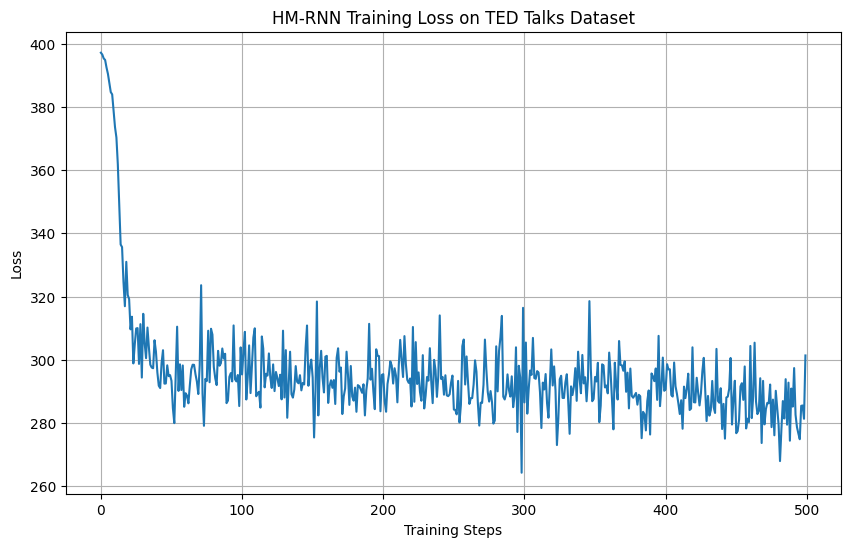


Final Results:
- Final loss: 301.3427
- Total training steps: 500
- Model saved as: HMRNN_TED.pkl
- Trained on 220585 characters from TED talk titles
- Vocabulary size: 52 characters

FINAL SAMPLE GENERATION

Sampling with seed: 'how to'
----------------------------------------

SAMPLES Segmented according to b1:

n| |o| |a|m|m|u|n|e|c|e|e|s|r| s|t|i|d|e|y|v|s| |t|p| |r|w|p|t|e|i|d|y|c|t|1|u|c|l|e| |o|e| |o|ae| |i|n|e|t|s|r|h| |a| |o|j|t|n|s|h| |l|i|n|f| |o|e|a|n| |h|u|e|g| |h|o|p| |e|e|?|n| |o| |h|a|l|a| |r|

SAMPLES Segmented according to b2:

n| o ammuneceesr stideyvs tp rwpteid|yct1ucle oe oae inetsr|h a ojt|nsh linf o|ean hueg hop ee?n o hala r

SAMPLES Segmented according to b3:

n o ammuneceesr stideyvs tp rwpteidyct1ucle oe oae inetsrh a ojtnsh linf oean hueg hop ee?n o hala r

Sampling with seed: 'the future'
----------------------------------------

SAMPLES Segmented according to b1:

p|w|r|,|i|a|k|i|t|i| |a|c|t|e| |n| |p|a|n|o| |t| |a|f|e|r|u|n| |,|c|r| |j|r|b|h|i|g|o|v|o|e

In [ ]:
# CELL 9: Fixed Final Evaluation and Results
# Run this cell after training completes

# Access global variables
global losses, data, save_name

# Plot training loss (with error handling)
try:
    if losses:
        plt.figure(figsize=(10, 6))
        plt.plot(losses)
        plt.title('HM-RNN Training Loss on TED Talks Dataset')
        plt.xlabel('Training Steps')
        plt.ylabel('Loss')
        plt.grid(True)
        plt.show()
    else:
        print("No loss data to plot")
except Exception as e:
    print(f"Could not plot losses: {e}")

# Final results
print(f"\nFinal Results:")
if losses:
    print(f"- Final loss: {losses[-1]:.4f}")
    print(f"- Total training steps: {len(losses)}")
else:
    print("- No training completed")

print(f"- Model saved as: {save_name}.pkl")

# Use the correct data attribute
try:
    if hasattr(data, 'data_indices'):
        print(f"- Trained on {len(data.data_indices)} characters from TED talk titles")
    else:
        print("- Training data length unknown")
    print(f"- Vocabulary size: {data.n_chars} characters")
except Exception as e:
    print(f"- Could not get data info: {e}")

# Generate final samples with different seeds
print("\n" + "="*60)
print("FINAL SAMPLE GENERATION")
print("="*60)

test_seeds = ["how to", "the future", "why we", "what if"]

for seed in test_seeds:
    print(f"\nSampling with seed: '{seed}'")
    print("-" * 40)
    try:
        sample(start_letters=seed, theta=0.3)
    except Exception as e:
        print(f"Error sampling with seed '{seed}': {e}")

print("\nHM-RNN training and evaluation complete!")
print("The model has learned hierarchical patterns in TED talk titles.")
print("The | marks show where the model detects boundaries at different levels:")
print("- b1 (frequent): word/phrase boundaries")
print("- b2 (medium): topic boundaries")
print("- b3 (rare): major conceptual boundaries")

# Additional model info
try:
    total_params = sum(p.numel() for p in rnn.parameters())
    trainable_params = sum(p.numel() for p in rnn.parameters() if p.requires_grad)
    print(f"\nModel Statistics:")
    print(f"- Total parameters: {total_params:,}")
    print(f"- Trainable parameters: {trainable_params:,}")
    print(f"- Model size: ~{total_params * 4 / 1024 / 1024:.2f} MB")
except Exception as e:
    print(f"Could not get model statistics: {e}")